# Prediktion av svenska bostadspriser med maskininlärning

Vi läser in csv-filen och skriver ut info och ett utdrag av tabellen

In [307]:
import pandas as pd
import numpy as np

df_original = pd.read_csv(
    "../data/SwedenHousingPrices.csv",
    encoding="utf-8-sig"
)

df = df_original.copy()

print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 11549 entries, 0 to 11548
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ad_id             11549 non-null  int64  
 1   date_published    11549 non-null  str    
 2   typology          11549 non-null  str    
 3   asking_price_sek  11549 non-null  float64
 4   land_area_sqm     11549 non-null  float64
 5   living_area_sqm   11549 non-null  float64
 6   sqm_price_sek     11549 non-null  float64
 7   number_rooms      11549 non-null  float64
 8   address           11547 non-null  str    
 9   location          11549 non-null  str    
 10  coordenates       11549 non-null  str    
dtypes: float64(5), int64(1), str(5)
memory usage: 1.9 MB
None


,ad_id,date_published,typology,asking_price_sek,land_area_sqm,living_area_sqm,sqm_price_sek,number_rooms,address,location,coordenates
0,21440984,2024-12-28,APARTMENT,3695000.0,0.0,82.0,45061.0,4.0,Einar Hansens esplanad 14,"Västra Hamnen, Malmö kommun","55.6118431,12.9822884"
1,21462070,2024-12-28,APARTMENT,3095000.0,0.0,109.0,28394.0,4.0,Skarpskyttevägen 30A,"Norra Fäladen, Lunds kommun","55.7230072,13.1973028"
2,21455084,2024-12-28,APARTMENT,2295000.0,0.0,54.0,42500.0,2.0,Boplatsvägen 9,"Brotorp/järvastaden, Sundbybergs kommun","59.381943,17.973993"
3,21411619,2024-12-28,APARTMENT,3675000.0,0.0,119.0,30882.0,4.0,Drottninggatan 34C,"Alingsås, Alingsås kommun","57.93111,12.5369"
4,21461458,2024-12-28,APARTMENT,295000.0,0.0,99.0,2980.0,4.0,Valhallagatan 19A,"Skara, Skara kommun","58.38283,13.4190693"


# Datatvätt

Ta bort kolumner vi inte vill ha med

In [308]:
df = df.drop(columns=["ad_id", "address", "sqm_price_sek", "date_published"])

Dela upp coordenates i nya kolumner "latitude" och "longitude" och ta bort coordenates

In [309]:
df[["latitude", "longitude"]] = df["coordenates"].str.split(",", expand=True).astype(float)

df = df.drop(columns=["coordenates"])


Skapa kolumn för municipality (kommun) och ta bort location

In [310]:
df["municipality"] = df["location"].str.split(", ").str[1]

df = df.drop(columns=["location"])

Ta bort rader med 0-värde för bostadsyta och antal rum

In [311]:
df = df[(df["living_area_sqm"] > 0) & (df["number_rooms"] > 0)].copy()

Ta bort allt som inte är lägenheter, hus eller radhus

In [312]:
df = df[df["typology"].isin(["APARTMENT", "HOUSE", "ROW_HOUSE"])].copy()

One Hot Encoding på municipality

In [313]:
df = pd.get_dummies(df, columns=["municipality"])

Gör "normala" kopior av den städade df för våra specialiserade modeller

In [314]:
normal = (
    (df["asking_price_sek"] <= 10_000_000) &
    (df["living_area_sqm"] <= 400) &
    (df["land_area_sqm"] <= 4_000)
)

df_global = df.copy()
df_apartment = df[(df["typology"] == "APARTMENT") & normal].copy()
df_house = df[(df["typology"] == "HOUSE") & normal].copy()
df_row_house = df[(df["typology"] == "ROW_HOUSE") & normal].copy()

Ta bort typology från de specialiserade dataseten

In [315]:
df_apartment = df_apartment.drop(columns=["typology"])
df_house = df_house.drop(columns=["typology"])
df_row_house = df_row_house.drop(columns=["typology"])

One Hot Encoding på typology i global-setet

In [316]:
df_global = pd.get_dummies(df_global, columns=["typology"])

Spara dataset på disk

In [317]:
import joblib

joblib.dump(df_global, "../data/df_global.pkl")
joblib.dump(df_apartment, "../data/df_apartment.pkl")
joblib.dump(df_house, "../data/df_house.pkl")
joblib.dump(df_row_house, "../data/df_row_house.pkl")

['../data/df_row_house.pkl']

# Global modell (kommer tränas på både lägenheter, hus och radhus)

Dela upp data i X och y

In [318]:
X_global = df_global.drop("asking_price_sek", axis=1)
y_global = df_global["asking_price_sek"]

Dela upp datan i train / val / test

In [319]:
from sklearn.model_selection import train_test_split

X_train_val_global, X_test_global, y_train_val_global, y_test_global = train_test_split(
    X_global, y_global, test_size=0.2, random_state=42
)

X_train_global, X_val_global, y_train_global, y_val_global = train_test_split(
    X_train_val_global, y_train_val_global, test_size=0.25, random_state=42
)

Skapa och träna en Random Forest modell med bäst uttestade parametrar och förutspå värden för lägenheter, hus och radhus

In [320]:
from sklearn.ensemble import RandomForestRegressor

rf_global = RandomForestRegressor(
    n_estimators=500,
    max_features=1.0,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_global.fit(X_train_global, y_train_global)

global_pred = rf_global.predict(X_val_global)

# Specialiserad lägenhetsmodell

Dela upp i X och y

In [321]:
X_apartment = df_apartment.drop(columns=["asking_price_sek"])
y_apartment = df_apartment["asking_price_sek"]

Dela upp i train / val / test

In [322]:
X_train_val_apartment, X_test_apartment, y_train_val_apartment, y_test_apartment = train_test_split(
    X_apartment,
    y_apartment,
    test_size=0.2,
    random_state=42
)

X_train_apartment, X_val_apartment, y_train_apartment, y_val_apartment = train_test_split(
    X_train_val_apartment,
    y_train_val_apartment,
    test_size=0.25,
    random_state=42
)

Skapa och träna en Random Forest modell med bäst uttestade parametrar och förutspå värden

In [323]:
rf_apartment = RandomForestRegressor(
    n_estimators=500,
    max_features=1.0,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_apartment.fit(X_train_apartment, y_train_apartment)

apartment_pred = rf_apartment.predict(X_val_apartment)

# Specialiserad husmodell

Dela upp data i X och y

In [324]:
X_house = df_house.drop(columns=["asking_price_sek"])
y_house = df_house["asking_price_sek"]

Dela upp i train / val / test

In [325]:
X_train_val_house, X_test_house, y_train_val_house, y_test_house = train_test_split(
    X_house,
    y_house,
    test_size=0.2,
    random_state=42
)

X_train_house, X_val_house, y_train_house, y_val_house = train_test_split(
    X_train_val_house,
    y_train_val_house,
    test_size=0.25,
    random_state=42
)

Skapa och träna en Random Forest modell med bäst uttestade parametrar och förutspå värden

In [326]:
rf_house = RandomForestRegressor(
    n_estimators=500,
    max_features=1.0,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_house.fit(X_train_house, y_train_house)

house_pred = rf_house.predict(X_val_house)

# Specialiserad radhusmodell

Dela upp data i X och y

In [327]:
X_row_house = df_row_house.drop(columns=["asking_price_sek"])
y_row_house = df_row_house["asking_price_sek"]

Dela upp i train / val / test

In [328]:
X_train_val_row_house, X_test_row_house, y_train_val_row_house, y_test_row_house = train_test_split(
    X_row_house,
    y_row_house,
    test_size=0.2,
    random_state=42
)

X_train_row_house, X_val_row_house, y_train_row_house, y_val_row_house = train_test_split(
    X_train_val_row_house,
    y_train_val_row_house,
    test_size=0.25,
    random_state=42
)

Skapa och träna en Random Forest modell med bäst uttestade parametrar och förutspå värden

In [329]:
rf_row_house = RandomForestRegressor(
    n_estimators=500,
    max_features=1.0,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_row_house.fit(X_train_row_house, y_train_row_house)

row_house_pred = rf_row_house.predict(X_val_row_house)

# Jämför modellerna

In [330]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

comparison = pd.DataFrame({
    "Model": [
        "Global Random Forest",
        "Apartment",
        "Row House",
        "House"
    ],
    "MAE (kr)": [
        mean_absolute_error(y_val_global, global_pred),
        mean_absolute_error(y_val_apartment, apartment_pred),
        mean_absolute_error(y_val_row_house, row_house_pred),
        mean_absolute_error(y_val_house, house_pred)
    ],
    "RMSE (kr)": [
        np.sqrt(mean_squared_error(y_val_global, global_pred)),
        np.sqrt(mean_squared_error(y_val_apartment, apartment_pred)),
        np.sqrt(mean_squared_error(y_val_row_house, row_house_pred)),
        np.sqrt(mean_squared_error(y_val_house, house_pred))
    ]
})

comparison["MAE (kr)"] = comparison["MAE (kr)"].round(0).astype(int)
comparison["RMSE (kr)"] = comparison["RMSE (kr)"].round(0).astype(int)

comparison

,Model,MAE (kr),RMSE (kr)
0,Global Random Forest,750156,1750608
1,Apartment,492586,762434
2,Row House,688322,955686
3,House,1126006,1462405


Resultat: Den specialiserade husmodellen är sämre på att förutspå hus än den globala modellen är på att förutspå en blandning av lägenheter, hus och radhus.

---

# Träna om modellerna på train_val och förutspå på X_test

In [331]:
rf_global.fit(X_train_val_global, y_train_val_global)
rf_apartment.fit(X_train_val_apartment, y_train_val_apartment)
rf_house.fit(X_train_val_house, y_train_val_house)
rf_row_house.fit(X_train_val_row_house, y_train_val_row_house)

global_pred = rf_global.predict(X_test_global)
apartment_pred = rf_apartment.predict(X_test_apartment)
house_pred = rf_house.predict(X_test_house)
row_house_pred = rf_row_house.predict(X_test_row_house)

In [332]:
comparison = pd.DataFrame({
    "Model": [
        "Global Random Forest",
        "Apartment",
        "Row House",
        "House"
    ],
    "MAE (kr)": [
        mean_absolute_error(y_test_global, global_pred),
        mean_absolute_error(y_test_apartment, apartment_pred),
        mean_absolute_error(y_test_row_house, row_house_pred),
        mean_absolute_error(y_test_house, house_pred)
    ],
    "RMSE (kr)": [
        np.sqrt(mean_squared_error(y_test_global, global_pred)),
        np.sqrt(mean_squared_error(y_test_apartment, apartment_pred)),
        np.sqrt(mean_squared_error(y_test_row_house, row_house_pred)),
        np.sqrt(mean_squared_error(y_test_house, house_pred))
    ]
})

comparison["MAE (kr)"] = comparison["MAE (kr)"].round(0).astype(int)
comparison["RMSE (kr)"] = comparison["RMSE (kr)"].round(0).astype(int)

comparison

,Model,MAE (kr),RMSE (kr)
0,Global Random Forest,667922,1124755
1,Apartment,451436,707747
2,Row House,758833,1047351
3,House,1125795,1475666


---

# Global-modellens resultat på endast lägenheter, radhus eller hus

In [333]:
# Jämförelse av MAE och RMSE mellan specialiserade och globala modeller

results = []

# --------------------------------------------------
# Global modell – alla bostadstyper
# --------------------------------------------------

# Gör prediktioner för hela validation-datasetet
global_all_pred = rf_global.predict(X_test_global)

# Beräkna MAE för den globala modellen
global_all_mae = mean_absolute_error(
    y_test_global,
    global_all_pred
)

# Beräkna RMSE för den globala modellen
global_all_rmse = np.sqrt(
    mean_squared_error(
        y_test_global,
        global_all_pred
    )
)

# --------------------------------------------------
# Jämför varje bostadstyp
# --------------------------------------------------

for typ, name, model, X_val, y_val in [
    ("typology_APARTMENT", "Lägenheter", rf_apartment, X_test_apartment, y_test_apartment),
    ("typology_ROW_HOUSE", "Radhus", rf_row_house, X_test_row_house, y_test_row_house),
    ("typology_HOUSE", "Hus", rf_house, X_test_house, y_test_house)
]:

    # Prediktioner från den specialiserade modellen
    specialized_pred = model.predict(X_val)

    # MAE för den specialiserade modellen
    specialized_mae = mean_absolute_error(
        y_val,
        specialized_pred
    )

    # RMSE för den specialiserade modellen
    specialized_rmse = np.sqrt(
        mean_squared_error(
            y_val,
            specialized_pred
        )
    )

    # --------------------------------------------------
    # Global modell – endast aktuell bostadstyp
    # --------------------------------------------------

    # Hitta rader som tillhör aktuell bostadstyp
    mask = X_test_global[typ]

    # Plocka ut endast denna bostadstyp från global validation-data
    X_test_global_type = X_test_global[mask]
    y_test_global_type = y_test_global[mask]

    # Gör prediktioner med den globala modellen
    global_pred = rf_global.predict(X_test_global_type)

    # MAE för den globala modellen på aktuell bostadstyp
    global_type_mae = mean_absolute_error(
        y_test_global_type,
        global_pred
    )

    # RMSE för den globala modellen på aktuell bostadstyp
    global_type_rmse = np.sqrt(
        mean_squared_error(
            y_test_global_type,
            global_pred
        )
    )

    # --------------------------------------------------
    # Spara resultaten
    # --------------------------------------------------

    results.append([
        name,
        round(specialized_mae),
        round(specialized_rmse),
        round(global_all_mae),
        round(global_all_rmse),
        round(global_type_mae),
        round(global_type_rmse)
    ])


# --------------------------------------------------
# Skapa en DataFrame med resultaten
# --------------------------------------------------

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Bostadstyp",
        "Specialiserad modell MAE",
        "Specialiserad modell RMSE",
        "Global modell – alla typer MAE",
        "Global modell – alla typer RMSE",
        "Global modell – endast typ MAE",
        "Global modell – endast typ RMSE"
    ]
)

# Visa jämförelsen
comparison_df

,Bostadstyp,Specialiserad modell MAE,Specialiserad modell RMSE,Global modell – alla typer MAE,Global modell – alla typer RMSE,Global modell – endast typ MAE,Global modell – endast typ RMSE
0,Lägenheter,451436,707747,667922,1124755,484720,845437
1,Radhus,758833,1047351,667922,1124755,842753,1308053
2,Hus,1125795,1475666,667922,1124755,1185545,1684745


Om de specialiserade modellerna presterar bättre eller inte beror på vilket värde vi anger för "normal"-parametern. Vid ett värde på upp till 10M så presterar specialmodellerna bäst.

---

# Feature importance – jämförelse mellan bostadstyper


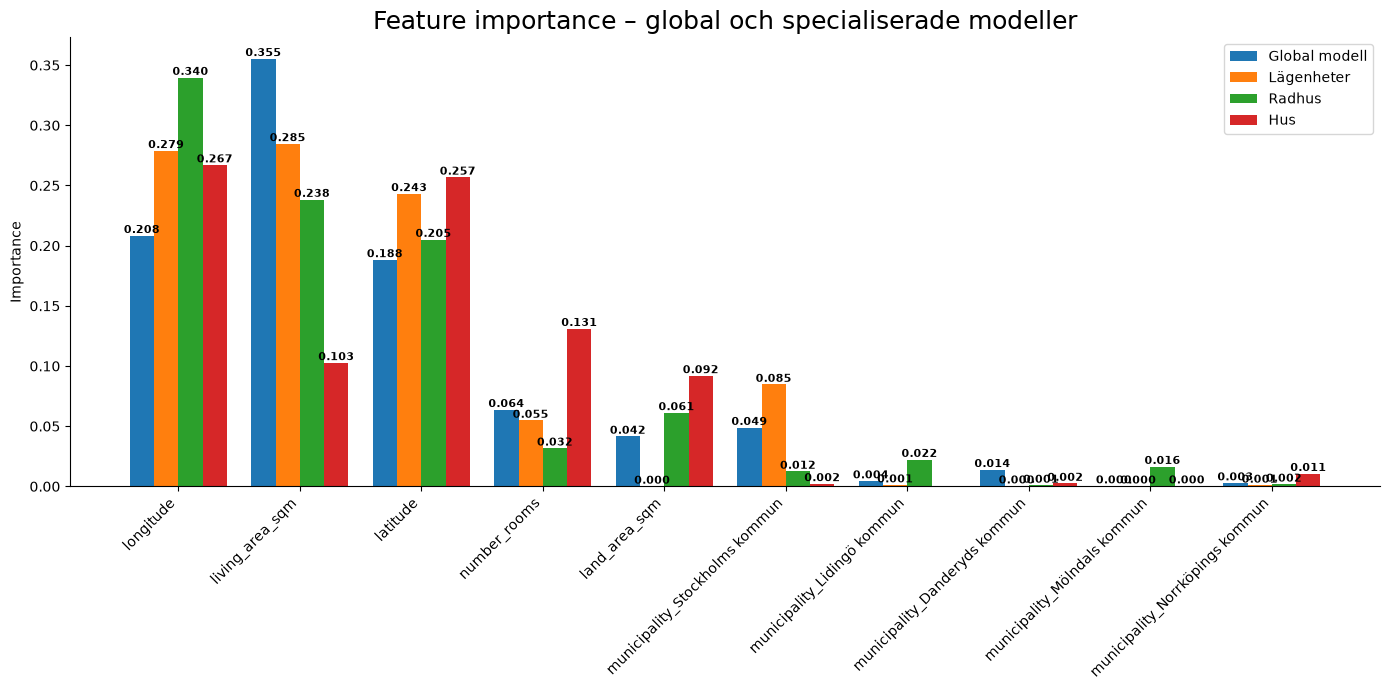

In [334]:
import matplotlib.pyplot as plt
import numpy as np

# Hämta feature importance från modellerna
importance_global = pd.Series(
    rf_global.feature_importances_,
    index=X_global.columns
)

importance_apartment = pd.Series(
    rf_apartment.feature_importances_,
    index=X_apartment.columns
)

importance_row_house = pd.Series(
    rf_row_house.feature_importances_,
    index=X_row_house.columns
)

importance_house = pd.Series(
    rf_house.feature_importances_,
    index=X_house.columns
)

# Hitta de 10 viktigaste features totalt
top_features = (
    importance_global
    .add(importance_apartment, fill_value=0)
    .add(importance_row_house, fill_value=0)
    .add(importance_house, fill_value=0)
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Hämta importance för dessa features
global_values = importance_global.reindex(top_features, fill_value=0)
apartment_values = importance_apartment.reindex(top_features, fill_value=0)
row_house_values = importance_row_house.reindex(top_features, fill_value=0)
house_values = importance_house.reindex(top_features, fill_value=0)

# Positioner för staplarna
x = np.arange(len(top_features))
width = 0.20

# Skapa diagram
fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(
    x - 1.5 * width,
    global_values,
    width,
    label="Global modell"
)

bars2 = ax.bar(
    x - 0.5 * width,
    apartment_values,
    width,
    label="Lägenheter"
)

bars3 = ax.bar(
    x + 0.5 * width,
    row_house_values,
    width,
    label="Radhus"
)

bars4 = ax.bar(
    x + 1.5 * width,
    house_values,
    width,
    label="Hus"
)

# Lägg till värden ovanför staplarna
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()

        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold"
            )

# Rubrik och axlar
ax.set_title("Feature importance – global och specialiserade modeller", fontsize=18)
ax.set_ylabel("Importance")
ax.set_xticks(x)
ax.set_xticklabels(top_features, rotation=45, ha="right")

# Förklaring
ax.legend()

# Ta bort onödiga kanter
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [335]:
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    {
        "model": rf_global,
        "feature_columns": X_global.columns.tolist()
    },
    MODELS_DIR / "global_random_forest.joblib"
)

joblib.dump(
    {
        "model": rf_apartment,
        "feature_columns": X_apartment.columns.tolist()
    },
    MODELS_DIR / "apartment_random_forest.joblib"
)

joblib.dump(
    {
        "model": rf_house,
        "feature_columns": X_house.columns.tolist()
    },
    MODELS_DIR / "house_random_forest.joblib"
)

joblib.dump(
    {
        "model": rf_row_house,
        "feature_columns": X_row_house.columns.tolist()
    },
    MODELS_DIR / "row_house_random_forest.joblib"
)

['..\\models\\row_house_random_forest.joblib']